In [10]:
import paddlenlp
from datasets import load_dataset

train_dataset_path = "data/data174918/train.json"
dev_dataset_path = "data/data174918/dev.json"
test_dataset_path = "data/data174918/test.json"
dataset = load_dataset("json",
                       data_files={
                           "train":train_dataset_path,
                            "dev":dev_dataset_path,
                            "test":test_dataset_path})
dataset["test"][:3]

{'text': ['共 同 创 造 美 好 的 新 世 纪 — — 二 ○ ○ 一 年 新 年 贺 词',
  '( 二 ○ ○ ○ 年 十 二 月 三 十 一 日 ) ( 附 图 片 1 张 )',
  '女 士 们 , 先 生 们 , 同 志 们 , 朋 友 们 :'],
 'label': ['B E B E B E S S B E B E B M M M E B E B E',
  'S B M M M E B M E B M M E S S S B E S S S',
  'B E S S B E S S B E S S B E S S']}

In [11]:
from paddlenlp.transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
inputs = tokenizer(text="中文分词是一项重要的自然语言处理领域任务")
inputs

[2026-02-24 17:24:24,905] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-02-24 17:24:24,915] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-02-24 17:24:24,916] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json


{'input_ids': [101, 704, 3152, 1146, 6404, 3221, 671, 7555, 7028, 6206, 4638, 5632, 4197, 6427, 6241, 1905, 4415, 7566, 1818, 818, 1218, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [12]:
tokens = tokenizer.tokenize('中文分词是一项重要的自然语言处理领域任务')
print(tokens,'\n',len(tokens))
ids = tokenizer.convert_tokens_to_ids(tokens)
print(ids,'\n',len(ids))
tokens_ = tokenizer.convert_ids_to_tokens(ids)
print(tokens_,'\n',len(tokens_))
strings = tokenizer.convert_tokens_to_string(tokens)
print(strings)

['中', '文', '分', '词', '是', '一', '项', '重', '要', '的', '自', '然', '语', '言', '处', '理', '领', '域', '任', '务'] 
 20
[704, 3152, 1146, 6404, 3221, 671, 7555, 7028, 6206, 4638, 5632, 4197, 6427, 6241, 1905, 4415, 7566, 1818, 818, 1218] 
 20
['中', '文', '分', '词', '是', '一', '项', '重', '要', '的', '自', '然', '语', '言', '处', '理', '领', '域', '任', '务'] 
 20
中 文 分 词 是 一 项 重 要 的 自 然 语 言 处 理 领 域 任 务


In [13]:
from paddlenlp.transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
print(tokenizer.__class__)
inputs = tokenizer(text="中文分词是一项重要的自然语言处理领域任务")
inputs

[2026-02-24 17:24:28,675] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-02-24 17:24:28,677] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-02-24 17:24:28,687] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-02-24 17:24:28,687] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json


<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>


{'input_ids': [101, 704, 3152, 1146, 6404, 3221, 671, 7555, 7028, 6206, 4638, 5632, 4197, 6427, 6241, 1905, 4415, 7566, 1818, 818, 1218, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [14]:
def convert_example_to_feature(example,tokenizer,label2id,max_seq_len=256,is_infer=False):
    text = example['text'].strip().split(" ")
    encoded_inputs = tokenizer(text=text,
                                max_seq_len=max_seq_len,
                                is_split_into_words="token",
                                return_length=True)
    encoded_inputs['label'] = []
    if not is_infer:
        ids = []
        offset = 0
        for id,word_ids in enumerate(encoded_inputs['input_ids']):
            token = tokenizer.convert_ids_to_tokens([word_ids])[-1]
            if len(token)>=2 and token[:2]=='##':
                offset+=1
                ids.append(f_ids)
            elif token in ["[CLS]","[SEP]","[UNK]"]:
                offset+=1
                ids.append(label2id["O"])
            else:
                f_ids = label2id[example['label'].strip().split(" ")[id - offset]]
                ids.append(f_ids) 
        ids = ids[:max_seq_len] if len(ids)>=max_seq_len else ids
        encoded_inputs["label"] = ids
        assert len(encoded_inputs["label"]) == len(encoded_inputs["input_ids"]) ,f"{tokenizer.convert_ids_to_tokens(encoded_inputs['input_ids'])},\n,{len(encoded_inputs['label'])},{len(encoded_inputs['input_ids'])}"
    return encoded_inputs
model_name = "bert-base-chinese"
label2id = {"O":0, "B":1, "M":2, "E":3, "S":4}
tokenizer = AutoTokenizer.from_pretrained(model_name)

[2026-02-24 17:24:30,170] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-02-24 17:24:30,171] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-02-24 17:24:30,175] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-02-24 17:24:30,176] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json


In [15]:
example = {"text":"钱 其 琛 访 问 德 班", "label":"S B E B E B E"}
features = convert_example_to_feature(example, tokenizer, label2id,max_seq_len=256, is_infer=False)
features

/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2353: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:1925: UserWarning: Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
  warnings.warn(


{'input_ids': [101, 7178, 1071, 4422, 6393, 7309, 2548, 4408, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'length': 9, 'seq_len': 9, 'label': [0, 4, 1, 3, 1, 3, 1, 3, 0]}

In [16]:
from functools import partial
trans_fn = partial(convert_example_to_feature,tokenizer=tokenizer,label2id=label2id,max_seq_len=256)

columns = ["text", "label"]
train_dataset = dataset["train"].map(trans_fn, batched=False, remove_columns=columns)
dev_dataset = dataset["dev"].map(trans_fn, batched=False, remove_columns=columns)
test_dataset = dataset["test"].map(trans_fn, batched=False, remove_columns=columns)

print("train_dataset:", len(train_dataset))
print("dev_dataset:", len(dev_dataset))
print("test_dataset:", len(test_dataset))


train_dataset: 18031
dev_dataset: 1000
test_dataset: 1944


In [17]:

import paddle

def collate_fn(batch_data,pad_token_id=0,pad_token_type_id=0,pad_label_id=0):
    input_ids_list, token_type_ids_list, label_list = [], [], []
    max_len = 0
    for example in batch_data:
        input_ids, token_type_ids, label = example["input_ids"], example["token_type_ids"], example["label"]
        # 对各项数据进行文本填充
        input_ids_list.append(input_ids)
        token_type_ids_list.append(token_type_ids)
        label_list.append(label)
        # 保存序列最大长度
        max_len = max(max_len, len(input_ids))
    for i in range(len(input_ids_list)):
        cur_len = len(input_ids_list[i])
        input_ids_list[i] = input_ids_list[i] + [pad_token_id] * (max_len - cur_len)
        token_type_ids_list[i] = token_type_ids_list[i] + [pad_token_type_id] * (max_len - cur_len)
        label_list[i] = label_list[i] + [pad_label_id] * (max_len - cur_len)

    return paddle.to_tensor(input_ids_list),  paddle.to_tensor(token_type_ids_list), paddle.to_tensor(label_list)



In [18]:
from paddle.io import BatchSampler,DataLoader

batch_size = 4
train_sampler = BatchSampler(train_dataset,batch_size=batch_size,shuffle=True)
dev_sampler = BatchSampler(dev_dataset,batch_size=batch_size,shuffle=False)

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_sampler=train_sampler,
                              collate_fn=collate_fn)
dev_dataloder = DataLoader(
    dataset=dev_dataset,
    batch_sampler=dev_sampler,
    collate_fn=collate_fn
)
test_loader = DataLoader(dataset=test_dataset,
                         batch_sampler=dev_sampler,
                         collate_fn=collate_fn)


In [19]:
next(iter(train_dataloader))

W0224 17:24:41.667948 13085 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 8.9, Driver API Version: 13.0, Runtime API Version: 11.8


[Tensor(shape=[4, 107], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [[101 , 123 , 2131, 689 , 7415, 1730, 8121, 119 , 8137, 102 , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ,
          0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   , 0   ],
         [101 , 711 , 784 , 720 , 7566, 2193, 2397, 6956, 4638, 6981, 981 , 510 ,
          2094, 1957, 1469, 6716, 6804, 2339, 868 , 782 , 1447, 5023, 117 , 5543,
          1916, 2802, 4708

In [21]:
from paddlenlp.data import DataCollatorForTokenClassification
from paddle.io import BatchSampler,DataLoader

batch_size = 4
train_sampler = BatchSampler(train_dataset,batch_size=batch_size,shuffle=True)
dev_sampler = BatchSampler(dev_dataset,batch_size=batch_size,shuffle=False)

data_collator = DataCollatorForTokenClassification(tokenizer,
                                                   label_pad_token_id=label2id["O"])
train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, collate_fn=data_collator)
dev_loader = DataLoader(dataset=dev_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)
test_loader = DataLoader(dataset=test_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)

In [22]:
next(iter(train_loader))

{'input_ids': Tensor(shape=[4, 256], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [[101 , 100 , 5988, ..., 0   , 0   , 0   ],
         [101 , 1780, 2898, ..., 679 , 2828, 102 ],
         [101 , 6421, 741 , ..., 0   , 0   , 0   ],
         [101 , 4197, 5445, ..., 0   , 0   , 0   ]]),
 'token_type_ids': Tensor(shape=[4, 256], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]),
 'length': Tensor(shape=[4], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [58 , 256, 92 , 108]),
 'seq_len': Tensor(shape=[4], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [58 , 256, 92 , 108]),
 'label': Tensor(shape=[4, 256], dtype=int64, place=Place(gpu:0), stop_gradient=True,
        [[0, 0, 4, ..., 0, 0, 0],
         [0, 1, 3, ..., 4, 4, 0],
         [0, 1, 3, ..., 0, 0, 0],
         [0, 1, 3, ..., 0, 0, 0]])}

In [23]:
from paddle import nn
class BertForTokenClassification(nn.Layer):
    def __init__(self,bert,num_class=2,droupt=None):
        self.num_class = num_class
        self.bert = bert
        self.droupt = nn.Dropout(droupt if droupt is not None else self.bert.config["hidden_dropout_prob"])
        self.classfier = nn.Linear(self.bert.config["hidden_size"],num_class)
    def forward(self,
                input_ids,
                token_type_ids=None,
                position_ids=None,
                attention_mask=None):
        outputs = self.bert(input_ids,
                            token_type_ids=token_type_ids,
                            position_ids=position_ids,
                            attention_mask=attention_mask)
        sequence_output = outputs[0]
        sequence_output = self.dropout(sequence_output)

        logits = self.classifier(sequence_output)

        return logits


In [24]:
from paddlenlp.transformers import AutoModelForTokenClassification

model_name= 'bert-base-chinese'
model = AutoModelForTokenClassification.from_pretrained(model_name, num_classes=5)
print(model.__class__)

[2026-02-24 17:24:57,588] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'> to load 'bert-base-chinese'.
[2026-02-24 17:24:57,589] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-02-24 17:24:57,590] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-02-24 17:24:57,840] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-02-24 17:24:57,905] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForTokenClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are in

<class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'>


In [25]:
from paddlenlp.metrics import ChunkEvaluator
import paddle
num_epochs = 3
lr = 3e-5
eval_steps = 100
log_steps = 2
save_dir = "./checkpoints"
weight_decay = 0.01
warmup_proportion = 0.1
num_training_steps = len(train_loader) * num_epochs
decay_params = [
    p.name for n,p in model.named_parameters()
    if not any(np in n for np in ['bias','norm'])
]
optimizer = paddle.optimizer.AdamW(
        learning_rate=lr,
        parameters=model.parameters(),
        weight_decay=weight_decay,
        apply_decay_param_fun=lambda x: x in decay_params)
loss_fn = nn.CrossEntropyLoss()

metric = ChunkEvaluator(label_list=label2id.keys())

In [27]:
def evaluate(model,dataloder,metric):
    model.eval()
    metric.reset()
    precision, recall, f1_score = 0, 0, 0
    with paddle.no_grad():
        for batch_data in dataloder:
            input_ids, token_type_ids, labels, seq_lens = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"], batch_data["seq_len"]
            logits = model(input_ids, token_type_ids)
            preditions = logits.argmax(axis=-1)
            num_infer_chunks, num_label_chunks, num_correct_chunks = metric.compute(seq_lens, preditions, labels)
            metric.update(num_infer_chunks.numpy(), num_label_chunks.numpy(), num_correct_chunks.numpy())
    precision, recall, f1_score = metric.accumulate()
        
    return precision, recall, f1_score

In [17]:
import os

def train(model):
    model.train()
    global_step = 0
    best_score = 0
    train_loss_record = []
    train_score_record = []
    
    for epoch in range(num_epochs):
        for step, batch_data in enumerate(train_loader):
            inputs, token_type_ids, labels = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"]
            logits = model(input_ids=inputs, token_type_ids=token_type_ids)
            loss = loss_fn(logits, labels) # 默认求mean
            train_loss_record.append((global_step, loss.item()))
            loss.backward()             
            optimizer.step()
            optimizer.clear_grad()
            if global_step % log_steps == 0:
                print(f"[Train] epoch: {epoch}/{num_epochs}, step: {global_step}/{num_training_steps}, loss: {loss.item():.5f}")
            
            if global_step != 0 and (global_step % eval_steps == 0 or global_step == (num_training_steps-1)):
                precision, recall, F1 = evaluate(model, dev_loader, metric)
                train_score_record.append((global_step, F1))
                model.train()
                # 如果当前指标为最优指标，保存该模型
                if F1 > best_score:
                    print(f"[Evaluate] best accuracy performence has been updated: {best_score:.5f} --> {F1:.5f}")
                    best_score = F1
                    save_path = os.path.join(save_dir, "best.pdparams")
                    paddle.save(model.state_dict(), save_path)
                print(f"[Evaluate]  precision: {precision: .5f}, recall: {recall: .5f}, dev score: {F1:.5f}")  
            global_step += 1

    save_path = os.path.join(save_dir, "final.pdparams")
    paddle.save(model.state_dict(), save_path)
    print("[Train] Training done!")

    return train_loss_record, train_score_record

train_loss_record, train_score_record = train(model)


W0224 16:36:47.094231  7519 gpu_resources.cc:243] WARNING: device: 0. The installed Paddle is compiled with CUDNN 8.9, but CUDNN version in your machine is 8.9, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDNN version.


[Train] epoch: 0/3, step: 0/13524, loss: 1.60567
[Train] epoch: 0/3, step: 2/13524, loss: 1.26591
[Train] epoch: 0/3, step: 4/13524, loss: 1.02764
[Train] epoch: 0/3, step: 6/13524, loss: 0.79338
[Train] epoch: 0/3, step: 8/13524, loss: 0.79200
[Train] epoch: 0/3, step: 10/13524, loss: 0.76311
[Train] epoch: 0/3, step: 12/13524, loss: 0.50396
[Train] epoch: 0/3, step: 14/13524, loss: 0.69091
[Train] epoch: 0/3, step: 16/13524, loss: 0.45508
[Train] epoch: 0/3, step: 18/13524, loss: 0.60421
[Train] epoch: 0/3, step: 20/13524, loss: 0.47777
[Train] epoch: 0/3, step: 22/13524, loss: 0.54231
[Train] epoch: 0/3, step: 24/13524, loss: 0.52932
[Train] epoch: 0/3, step: 26/13524, loss: 0.52035
[Train] epoch: 0/3, step: 28/13524, loss: 0.40152
[Train] epoch: 0/3, step: 30/13524, loss: 0.44965
[Train] epoch: 0/3, step: 32/13524, loss: 0.46613
[Train] epoch: 0/3, step: 34/13524, loss: 0.17512
[Train] epoch: 0/3, step: 36/13524, loss: 0.82970
[Train] epoch: 0/3, step: 38/13524, loss: 0.71566
[Trai

/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


[Evaluate] best accuracy performence has been updated: 0.00000 --> 0.74386
[Evaluate]  precision:  0.74747, recall:  0.74029, dev score: 0.74386
[Train] epoch: 0/3, step: 102/13524, loss: 0.15660
[Train] epoch: 0/3, step: 104/13524, loss: 0.11918
[Train] epoch: 0/3, step: 106/13524, loss: 0.26494
[Train] epoch: 0/3, step: 108/13524, loss: 0.39508
[Train] epoch: 0/3, step: 110/13524, loss: 0.64200
[Train] epoch: 0/3, step: 112/13524, loss: 0.13425
[Train] epoch: 0/3, step: 114/13524, loss: 0.18337
[Train] epoch: 0/3, step: 116/13524, loss: 0.42088
[Train] epoch: 0/3, step: 118/13524, loss: 0.47652
[Train] epoch: 0/3, step: 120/13524, loss: 0.31587
[Train] epoch: 0/3, step: 122/13524, loss: 0.40912
[Train] epoch: 0/3, step: 124/13524, loss: 0.51716
[Train] epoch: 0/3, step: 126/13524, loss: 0.33440
[Train] epoch: 0/3, step: 128/13524, loss: 0.44926
[Train] epoch: 0/3, step: 130/13524, loss: 0.11573
[Train] epoch: 0/3, step: 132/13524, loss: 0.30155
[Train] epoch: 0/3, step: 134/13524, lo

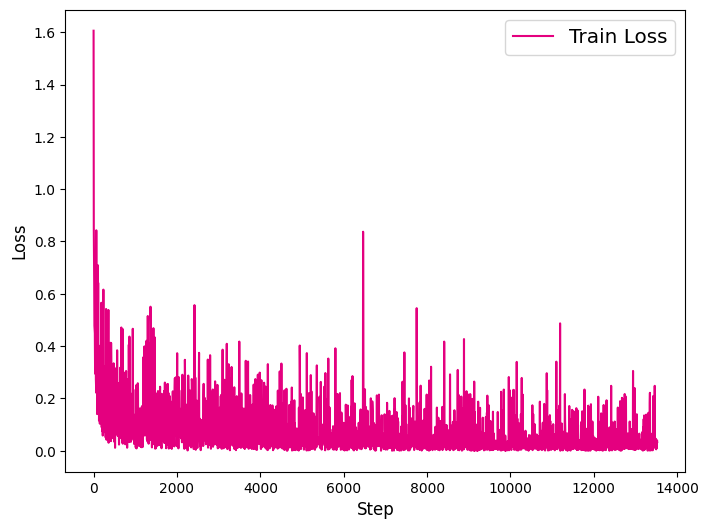

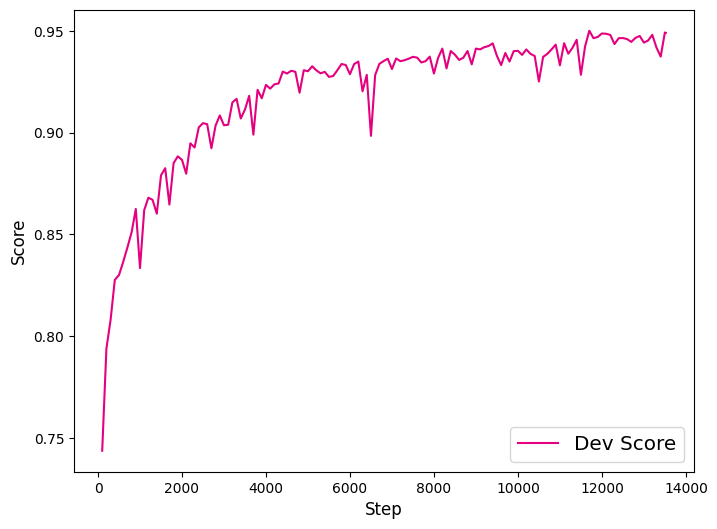

In [19]:
import matplotlib.pyplot as plt

def plot_training_loss(train_loss_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left"):
    plt.figure(figsize=fig_size)

    train_steps = [x[0] for x in train_loss_record][::sample_step]
    train_losses = [x[1] for x in train_loss_record][::sample_step]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Train Loss")
    plt.ylabel("Loss", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

def plot_training_acc(train_score_record, fig_name, fig_size=(8, 6), sample_step=10, acc_legend_loc="lower left"):

    plt.figure(figsize=fig_size)

    train_steps=[x[0] for x in train_score_record]
    train_losses = [x[1] for x in train_score_record]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Dev Score")
    # 绘制坐标轴和图例
    plt.ylabel("Score", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=acc_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

fig_path = "./images/chapter6_loss1.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=5)

fig_path = "./images/chapter6_acc1.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, acc_legend_loc="lower right")

In [28]:
saved_state = paddle.load("./checkpoints/best.pdparams")
model = AutoModelForTokenClassification.from_pretrained(model_name, num_classes=5)
model.load_dict(saved_state)


precision, recall, F1 = evaluate(model, test_loader, metric)
print(f"[Evaluate]  precision: {precision: .5f}, recall: {recall: .5f}, dev score: {F1:.5f}") 


[2026-02-24 17:25:21,145] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'> to load 'bert-base-chinese'.
[2026-02-24 17:25:21,145] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-02-24 17:25:21,146] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-02-24 17:25:21,312] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-02-24 17:25:21,370] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForTokenClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are in

[Evaluate]  precision:  0.95119, recall:  0.94641, dev score: 0.94879


In [31]:
from seqeval.metrics.sequence_labeling import get_entities

def parsing_label_sequence(tokens, label_sequence):
    prev = 0
    words = []
    items = get_entities(seq=label_sequence,suffix=False)
    for _, start, end in items:
        if prev != start:
            words.extend(tokens[prev:start])
        words.append("".join(tokens[start:end+1]))
        prev = end + 1
    
    return words

def pre(model,text,tokenizer, id2label):
    model.eval()
    with paddle.no_grad():
        encoded_inputs = tokenizer(text, max_seq_len=256)
        input_ids = paddle.to_tensor(encoded_inputs["input_ids"],
                                     dtype="int64").unsqueeze(0)
        token_type_ids = paddle.to_tensor(encoded_inputs["token_type_ids"],
                                          dtype="int64").unsqueeze(0)
        logits = model(input_ids=input_ids, token_type_ids=token_type_ids)
        predictions = logits.argmax(axis=-1).tolist()[0]
        label_sequence = [id2label[label_id] for label_id in predictions[1:-1]]
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist()[1:-1])
        words = parsing_label_sequence(tokens, label_sequence)
    print("tokenize sequence:", " | ".join(words))

text ="我想问问问问问我该怎么脱身你却说花花世界不必当真多么伤人让我爱上薄情的红唇"
id2label = {v:k for k, v in label2id.items()}
pre(model, text, tokenizer, id2label)

tokenize sequence: 我 | 想 | 问问 | 问问 | 问 | 我 | 该 | 怎么 | 脱身 | 你 | 却 | 说 | 花花世界 | 不必 | 当真 | 多么 | 伤人 | 让 | 我 | 爱 | 上 | 薄情 | 的 | 红唇
